# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [20]:
%pip -q install duckdb huggingface_hub


In [21]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [22]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [23]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [ ]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [6]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


In [8]:
data = features.merge(qsignals, on='content_hash_id', how='left')

print(f'joined: {len(data):,} rows')

data.head()

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


In [9]:
data['is_declining'] = (
    data['imp_last30'] < 0.8 * data['imp_prev30']
).astype(int)

print(data['is_declining'].value_counts())
print(data['is_declining'].value_counts(normalize=True))

is_declining
1    71547
0    39700
Name: count, dtype: int64
is_declining
1    0.643136
0    0.356864
Name: proportion, dtype: float64


In [10]:
feature_cols = [
    'imp_prev30',
    'visible_queries',
    'rare_share',
    'anon_share',
    'top_query_share'
]

model_data = data[
    ['client_hash_id', 'content_hash_id'] + feature_cols + ['is_declining']
].dropna().copy()

print(f'Modeling rows: {len(model_data):,}')
model_data.head()

Modeling rows: 102,203


,client_hash_id,content_hash_id,imp_prev30,visible_queries,rare_share,anon_share,top_query_share,is_declining
0,client_62f4a7e64f5e0096,content_0dac238195631de4,251.0,15.0,0.144623,0.665019,0.256494,0
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,4786.0,101.0,0.037423,0.178737,0.844021,1
2,client_62f4a7e64f5e0096,content_332f337f995e9781,177.0,3.0,0.215054,0.623656,0.416667,1
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,1518.0,16.0,0.032740,0.717915,0.496849,1
4,client_62f4a7e64f5e0096,content_742939be32c206d2,335.0,8.0,0.224066,0.630705,0.214286,0


In [11]:
from sklearn.model_selection import GroupShuffleSplit

X = model_data[feature_cols]
y = model_data['is_declining']
groups = model_data['client_hash_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")
print(f"Train clients: {groups.iloc[train_idx].nunique():,}")
print(f"Test clients:  {groups.iloc[test_idx].nunique():,}")

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train rows: 50,758
Test rows:  51,445
Train clients: 39
Test clients:  10

Train class distribution:
is_declining
1    0.585898
0    0.414102
Name: proportion, dtype: float64

Test class distribution:
is_declining
1    0.67853
0    0.32147
Name: proportion, dtype: float64


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_pred = [y_train.mode()[0]] * len(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("BASELINE")
print(f"Accuracy : {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall   : {baseline_recall:.3f}")
print(f"F1       : {baseline_f1:.3f}")

BASELINE
Accuracy : 0.679
Precision: 0.679
Recall   : 1.000
F1       : 0.808


In [16]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred, zero_division=0)
tree_recall = recall_score(y_test, tree_pred, zero_division=0)
tree_f1 = f1_score(y_test, tree_pred, zero_division=0)

print("DECISION TREE")
print(f"Accuracy : {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall   : {tree_recall:.3f}")
print(f"F1       : {tree_f1:.3f}")



DECISION TREE
Accuracy : 0.599
Precision: 0.710
Recall   : 0.692
F1       : 0.701


In [17]:
import pandas as pd

importance = (
    pd.Series(tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(importance)

visible_queries    0.335059
rare_share         0.323156
anon_share         0.173374
imp_prev30         0.155154
top_query_share    0.013258
dtype: float64


Confusion matrix:
[[ 6663  9875]
 [10741 24166]]


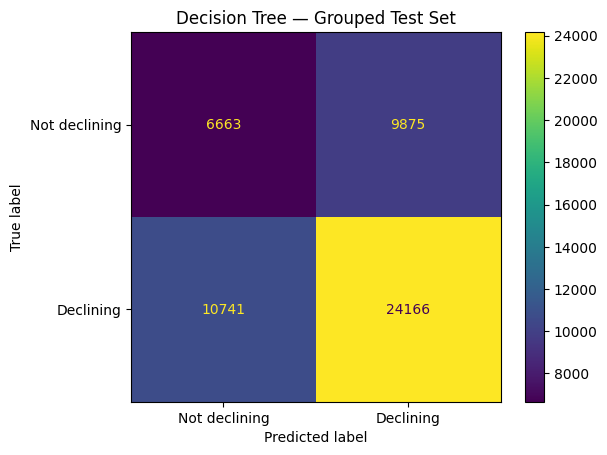

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, tree_pred)

print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not declining', 'Declining']
).plot()

plt.title("Decision Tree — Grouped Test Set")
plt.show()


In [19]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Decision Tree'],
    'Accuracy': [baseline_accuracy, tree_accuracy],
    'Precision': [baseline_precision, tree_precision],
    'Recall': [baseline_recall, tree_recall],
    'F1': [baseline_f1, tree_f1]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.678530,0.678530,1.000000,0.808482
1,Decision Tree,0.599261,0.709909,0.692297,0.700992


In [ ]:
signal_summary = model_data[
    [
        'imp_prev30',
        'visible_queries',
        'rare_share',
        'anon_share',
        'top_query_share'
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])

signal_summary